# 09B Alpha System Dashboard

Read-only Phase 2/3 dashboard for the current stable survivor alpha system before universe expansion.

In [12]:
from pathlib import Path
import gc
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif PROJECT_ROOT.name == "3-Phase 3_Portfolio Construction":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.alpha_dashboard import (
    average_dynamic_weights,
    best_portfolio_by_mode,
    cumulative_return_frame,
    drawdown_frame,
    expansion_readiness_summary,
    get_final_survivors,
    load_dashboard_tables,
    performance_comparison,
    portfolio_alpha_contribution,
    portfolio_return_series,
    rolling_performance_frame,
    rolling_survivor_correlation,
    stress_wfv_interpretation,
    survivor_correlation_matrix,
    system_overview,
)
from src.run_config import get_sqlite_db_path

pd.set_option("display.max_columns", 200)
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True

DB_PATH = get_sqlite_db_path()
DB_PATH

PosixPath('/Users/AnyiXu_1/Desktop/multi-factor-equity-alpha-model/sql/project_underdog.db')

In [13]:
tables = load_dashboard_tables(DB_PATH)

survivor_registry = tables["survivor_alpha_registry_current"]
pre_ml_alpha_inputs = tables["pre_ml_alpha_inputs_current"]
portfolio_alpha_pool = tables["portfolio_alpha_pool_current"]
portfolio_weights = tables["portfolio_weights_current"]
portfolio_backtest_results = tables["portfolio_backtest_results_current"]
portfolio_performance_summary = tables["portfolio_performance_summary_current"]
alpha_dynamic_weight_audit = tables["alpha_dynamic_weight_audit_current"]
alpha_stress_gate = tables["alpha_stress_gate_current"]
constructed_alpha_wfv_gate = tables["constructed_alpha_wfv_gate_current"]
signal_diversity_selection = tables["signal_diversity_selection_current"]
survivor_cluster_summary = tables["survivor_cluster_summary_current"]

loaded_tables = pd.DataFrame(
    [{"table_name": name, "rows": len(df), "columns": len(df.columns)} for name, df in tables.items()]
)
display(loaded_tables)

gc.collect()
if 'cleanup_memory' in globals():
    cleanup_memory('after loading dashboard tables')

,table_name,rows,columns
0,survivor_alpha_registry_current,2,30
1,pre_ml_alpha_inputs_current,1002844,8
2,portfolio_alpha_pool_current,4,17
3,portfolio_weights_current,7587888,7
4,portfolio_backtest_results_current,16424,10
5,portfolio_performance_summary_current,8,24
6,alpha_dynamic_weight_audit_current,44058,11
7,alpha_stress_gate_current,3,23
8,constructed_alpha_wfv_gate_current,24,18
9,signal_diversity_selection_current,1,21


## 1. System Overview

In [14]:
final_survivors = get_final_survivors(survivor_registry)
overview = system_overview(survivor_registry)

survivor_names = final_survivors["alpha_name"].dropna().tolist() if "alpha_name" in final_survivors else []
overview_metrics = pd.DataFrame(
    [
        {"metric": "n_final_survivors", "value": len(final_survivors)},
        {"metric": "survivor_names", "value": ", ".join(survivor_names)},
        {
            "metric": "alpha_behavior_clusters",
            "value": ", ".join(final_survivors.get("alpha_behavior_cluster", pd.Series(dtype=object)).dropna().unique()),
        },
    ]
)

display(overview_metrics)
display(overview)

,metric,value
0,n_final_survivors,1
1,survivor_names,alpha_regime_blend_dynamic_v4_smooth
2,alpha_behavior_clusters,CORE_REGIME


,alpha_name,horizon,alpha_behavior_cluster,original_promotion_decision,promotion_decision_final,source_wfv_status,stress_status,survivor_selection_score,final_status,cluster_selection_reason
0,alpha_regime_blend_dynamic_v4_smooth,20,CORE_REGIME,REVIEW_SATELLITE,PROMOTE_CORE,WATCHLIST_CONSTRUCTED_ALPHA_WFV,APPROVED_STRESS,49.596981,CORE_ALPHA_SURVIVOR,Best eligible alpha from a distinct behavior c...
1,alpha_hybrid_adaptive_v4_smooth,20,CORE_REGIME,REVIEW_SATELLITE,REVIEW_SATELLITE,WATCHLIST_CONSTRUCTED_ALPHA_WFV,APPROVED_STRESS,37.667225,SATELLITE_WATCHLIST,Score below MIN_CLUSTER_SCORE 40.


## 2. Portfolio Performance Summary

In [15]:
performance_table = performance_comparison(portfolio_performance_summary)
best_long_only = best_portfolio_by_mode(portfolio_performance_summary, "long_only")
best_long_short = best_portfolio_by_mode(portfolio_performance_summary, "long_short")

display(performance_table)
display(pd.DataFrame([row.to_dict() for row in [best_long_only, best_long_short] if row is not None]))

,portfolio_method,portfolio_mode,annualized_return,annualized_volatility,sharpe,max_drawdown,total_return,excess_return,avg_turnover
0,equal_weight_survivors,long_only_top,0.131278,0.194623,0.674525,-0.365286,1.731622,-0.315465,0.024172
1,hybrid_survivor_weighted_portfolio,long_only_top,0.131278,0.194623,0.674525,-0.365286,1.731622,-0.315465,0.024172
2,inverse_turnover_weighted_survivors,long_only_top,0.131278,0.194623,0.674525,-0.365286,1.731622,-0.315465,0.024172
3,stress_score_weighted_survivors,long_only_top,0.131278,0.194623,0.674525,-0.365286,1.731622,-0.315465,0.024172
4,equal_weight_survivors,long_short_top_bottom,0.045080,0.079885,0.564314,-0.149828,0.432217,-1.614870,0.019034
5,hybrid_survivor_weighted_portfolio,long_short_top_bottom,0.045080,0.079885,0.564314,-0.149828,0.432217,-1.614870,0.019034
6,inverse_turnover_weighted_survivors,long_short_top_bottom,0.045080,0.079885,0.564314,-0.149828,0.432217,-1.614870,0.019034
7,stress_score_weighted_survivors,long_short_top_bottom,0.045080,0.079885,0.564314,-0.149828,0.432217,-1.614870,0.019034


,portfolio_method,portfolio_mode,n_survivor_alphas,n_dates,n_tickers,annualized_return,annualized_volatility,sharpe,max_drawdown,hit_rate,total_return,benchmark_total_return,excess_return,avg_turnover,median_turnover,max_turnover,mean_gross_exposure,mean_net_exposure,active_day_pct,cost_bps,execution_lag,benchmark_source,run_id,portfolio_version
0,equal_weight_survivors,long_only_top,1,2053,462,0.131278,0.194623,0.674525,-0.365286,0.544082,1.731622,2.047087,-0.315465,0.024172,0.0,0.240506,1.0,1.000000e+00,1.0,5,1,benchmark_prices_current.SPY,phase9_nb09_portfolio_20260511_095939,phase9_survivor_portfolio_v1
1,equal_weight_survivors,long_short_top_bottom,1,2053,462,0.045080,0.079885,0.564314,-0.149828,0.515343,0.432217,2.047087,-1.614870,0.019034,0.0,0.160000,1.0,6.349950e-19,1.0,5,1,benchmark_prices_current.SPY,phase9_nb09_portfolio_20260511_095939,phase9_survivor_portfolio_v1


## 3. Equity Curve Visualization

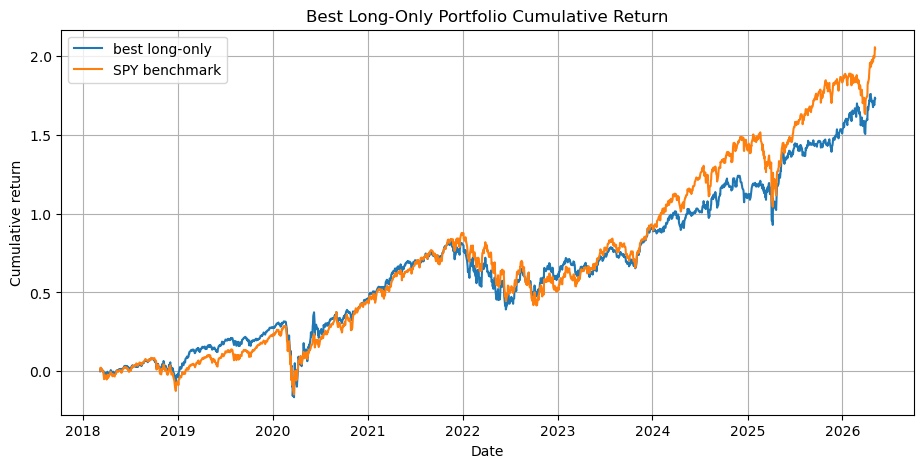

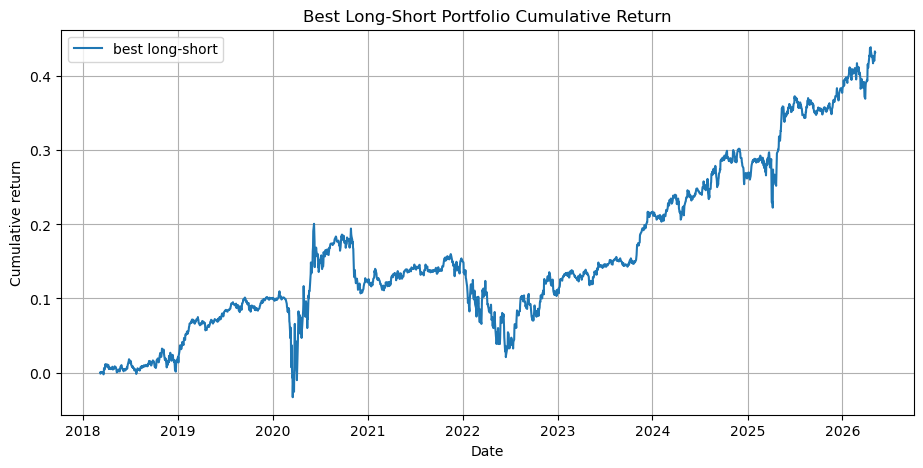

In [16]:
best_long_only_returns = portfolio_return_series(portfolio_backtest_results, best_long_only)
best_long_short_returns = portfolio_return_series(portfolio_backtest_results, best_long_short)

long_only_curve = cumulative_return_frame(best_long_only_returns)
long_short_curve = cumulative_return_frame(best_long_short_returns)

if not long_only_curve.empty:
    fig, ax = plt.subplots()
    ax.plot(long_only_curve["Date"], long_only_curve["portfolio_cumulative_return"], label="best long-only")
    if "benchmark_cumulative_return" in long_only_curve:
        ax.plot(long_only_curve["Date"], long_only_curve["benchmark_cumulative_return"], label="SPY benchmark")
    ax.set_title("Best Long-Only Portfolio Cumulative Return")
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative return")
    ax.legend()
    plt.show()

if not long_short_curve.empty:
    fig, ax = plt.subplots()
    ax.plot(long_short_curve["Date"], long_short_curve["portfolio_cumulative_return"], label="best long-short")
    ax.set_title("Best Long-Short Portfolio Cumulative Return")
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative return")
    ax.legend()
    plt.show()

## 4. Drawdown Visualization

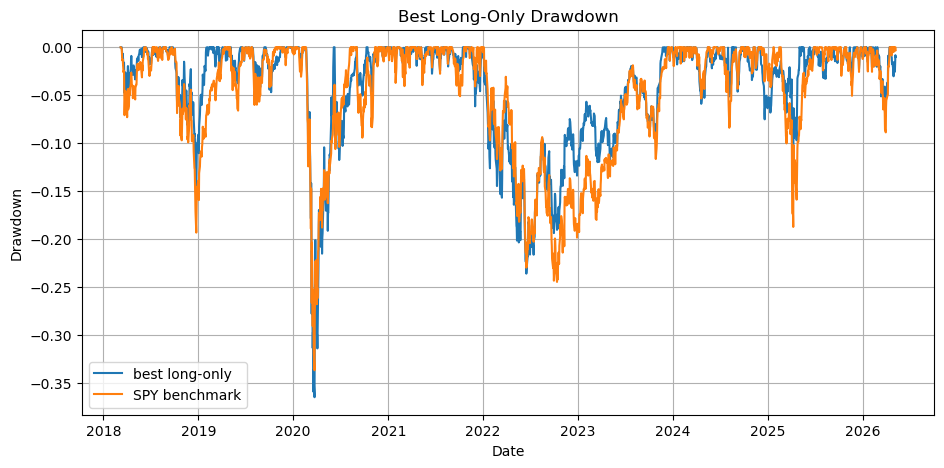

In [17]:
long_only_drawdown = drawdown_frame(best_long_only_returns)

if not long_only_drawdown.empty:
    fig, ax = plt.subplots()
    ax.plot(long_only_drawdown["Date"], long_only_drawdown["portfolio_drawdown"], label="best long-only")
    if "benchmark_drawdown" in long_only_drawdown:
        ax.plot(long_only_drawdown["Date"], long_only_drawdown["benchmark_drawdown"], label="SPY benchmark")
    ax.set_title("Best Long-Only Drawdown")
    ax.set_xlabel("Date")
    ax.set_ylabel("Drawdown")
    ax.legend()
    plt.show()

## 5. Rolling Performance

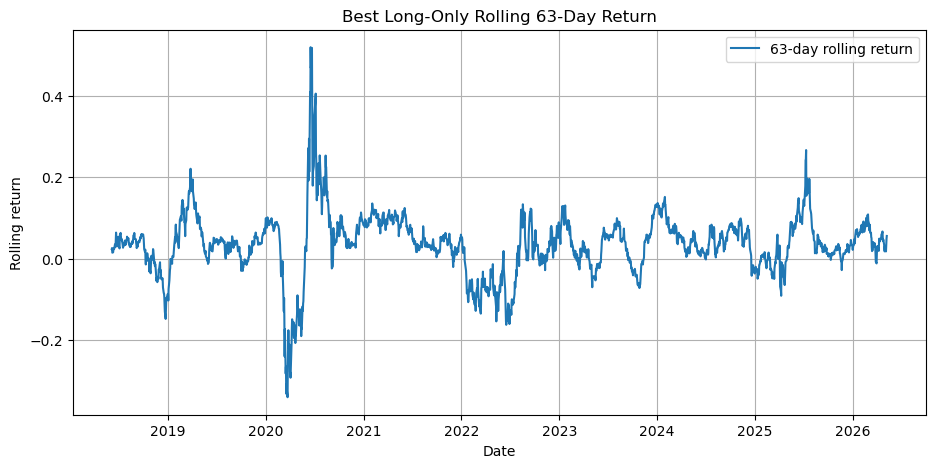

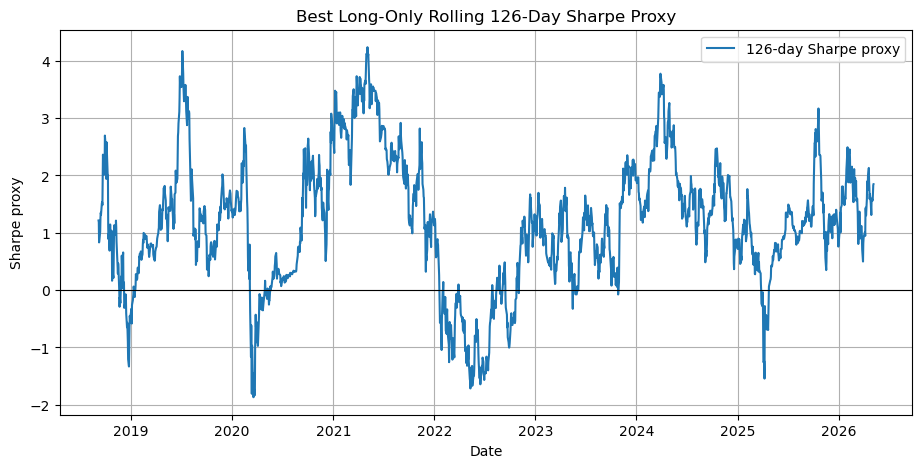

In [18]:
rolling_perf = rolling_performance_frame(best_long_only_returns)

if not rolling_perf.empty:
    fig, ax = plt.subplots()
    ax.plot(rolling_perf["Date"], rolling_perf["rolling_63d_return"], label="63-day rolling return")
    ax.set_title("Best Long-Only Rolling 63-Day Return")
    ax.set_xlabel("Date")
    ax.set_ylabel("Rolling return")
    ax.legend()
    plt.show()

    fig, ax = plt.subplots()
    ax.plot(rolling_perf["Date"], rolling_perf["rolling_126d_sharpe_proxy"], label="126-day Sharpe proxy")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("Best Long-Only Rolling 126-Day Sharpe Proxy")
    ax.set_xlabel("Date")
    ax.set_ylabel("Sharpe proxy")
    ax.legend()
    plt.show()

## 6. Survivor Alpha Contribution

,portfolio_method,alpha_name,horizon,component_weight,raw_weight_score,weighting_rule,survivor_tier,alpha_role,pass_rate,worst_degradation,avg_turnover_proxy
0,equal_weight_survivors,alpha_regime_blend_dynamic_v4_smooth,20,1.0,1.000000,equal_weight_survivors,WATCH_STRESS_SURVIVOR,CORE_ALPHA,0.888889,0.422319,1.746788
1,hybrid_survivor_weighted_portfolio,alpha_regime_blend_dynamic_v4_smooth,20,1.0,2.000000,hybrid_survivor_weighted_portfolio,WATCH_STRESS_SURVIVOR,CORE_ALPHA,0.888889,0.422319,1.746788
2,inverse_turnover_weighted_survivors,alpha_regime_blend_dynamic_v4_smooth,20,1.0,0.572479,inverse_turnover_weighted_survivors,WATCH_STRESS_SURVIVOR,CORE_ALPHA,0.888889,0.422319,1.746788
3,stress_score_weighted_survivors,alpha_regime_blend_dynamic_v4_smooth,20,1.0,0.624958,stress_score_weighted_survivors,WATCH_STRESS_SURVIVOR,CORE_ALPHA,0.888889,0.422319,1.746788


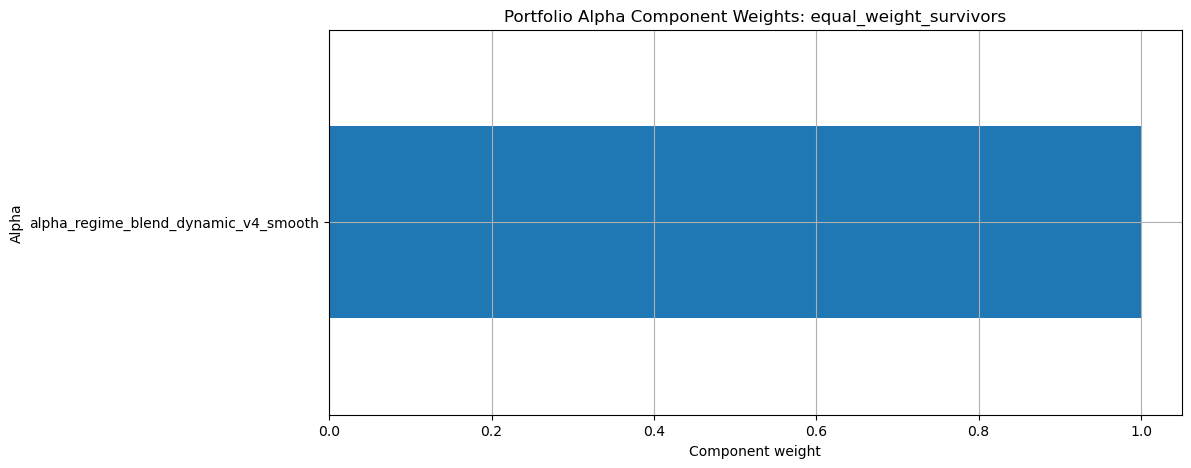

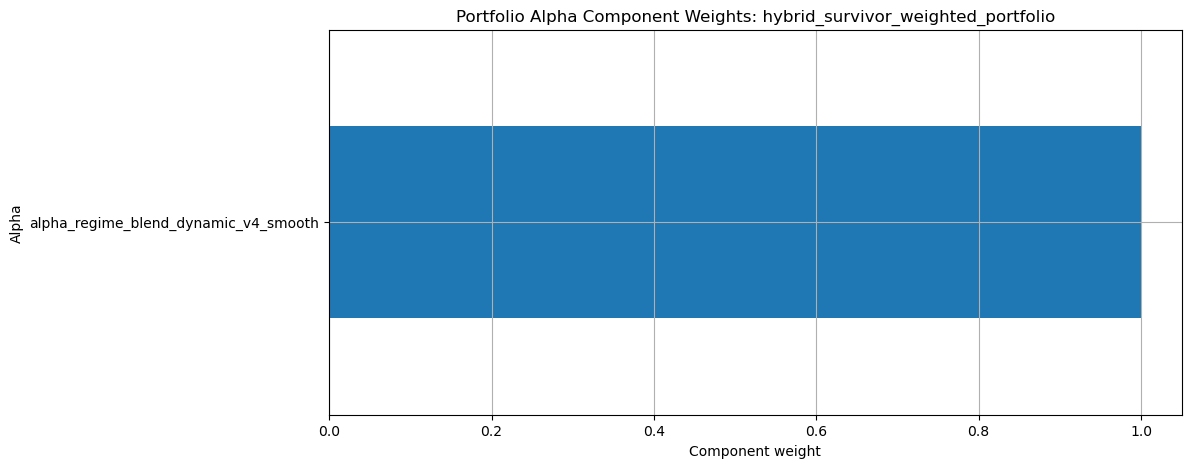

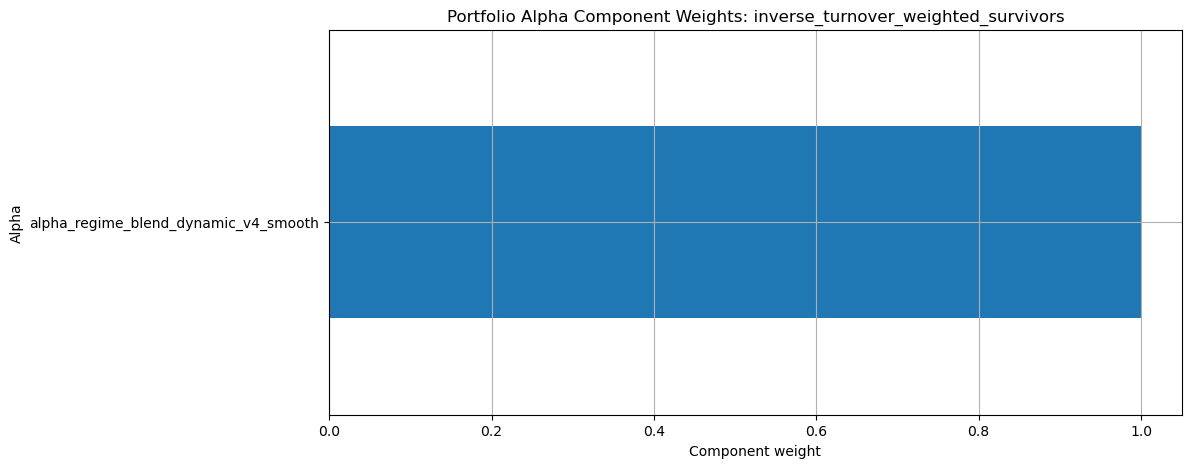

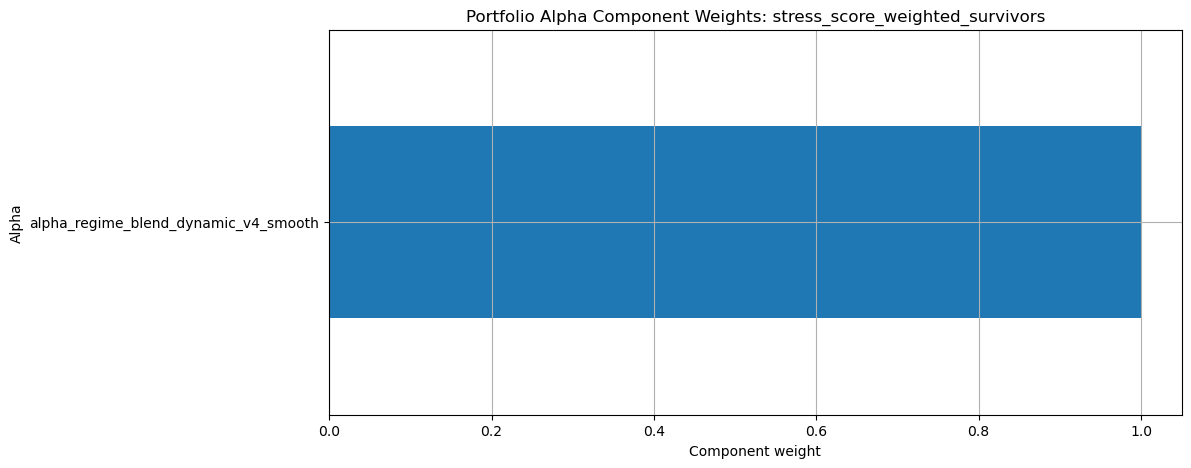

,note
0,No dynamic survivor weights available for curr...


In [19]:
contribution_table = portfolio_alpha_contribution(portfolio_alpha_pool, final_survivors)
dynamic_weights = average_dynamic_weights(alpha_dynamic_weight_audit, final_survivors)

display(contribution_table)

if not contribution_table.empty and {"portfolio_method", "alpha_name", "component_weight"}.issubset(contribution_table.columns):
    for method, group in contribution_table.groupby("portfolio_method"):
        fig, ax = plt.subplots()
        group.sort_values("component_weight", ascending=True).plot.barh(
            x="alpha_name",
            y="component_weight",
            ax=ax,
            legend=False,
        )
        ax.set_title(f"Portfolio Alpha Component Weights: {method}")
        ax.set_xlabel("Component weight")
        ax.set_ylabel("Alpha")
        plt.show()

if not dynamic_weights.empty:
    avg_weight_summary = (
        dynamic_weights.groupby("alpha_name", as_index=False)["weight"]
        .mean()
        .rename(columns={"weight": "avg_dynamic_component_weight"})
        .sort_values("avg_dynamic_component_weight", ascending=False)
    )
    display(avg_weight_summary)
    fig, ax = plt.subplots()
    for alpha_name, group in dynamic_weights.groupby("alpha_name"):
        ax.plot(group["Date"], group["weight"], label=alpha_name)
    ax.set_title("Average Dynamic Component Weights Through Time")
    ax.set_xlabel("Date")
    ax.set_ylabel("Average component weight")
    ax.legend()
    plt.show()
else:
    display(pd.DataFrame([{"note": "No dynamic survivor weights available for current final survivors."}]))

## 7. Alpha Correlation / Diversification

alpha_name,alpha_regime_blend_dynamic_v4_smooth
alpha_name,
alpha_regime_blend_dynamic_v4_smooth,1.0


,alpha_behavior_cluster,alpha_sleeve,n_candidates,n_promote_core_original,n_review_satellite,n_final_core,best_alpha_name,best_score,best_final_status,avg_abs_corr_with_selected_core,cluster_decision,survivor_version,run_id
0,CORE_REGIME,CORE_REGIME,2,0,2,1,alpha_regime_blend_dynamic_v4_smooth,49.596981,CORE_ALPHA_SURVIVOR,0.990363,FINAL_CORE_SELECTED,phase8_cluster_aware_survivor_v5,phase8_cluster_aware_survivor_20260511_084437


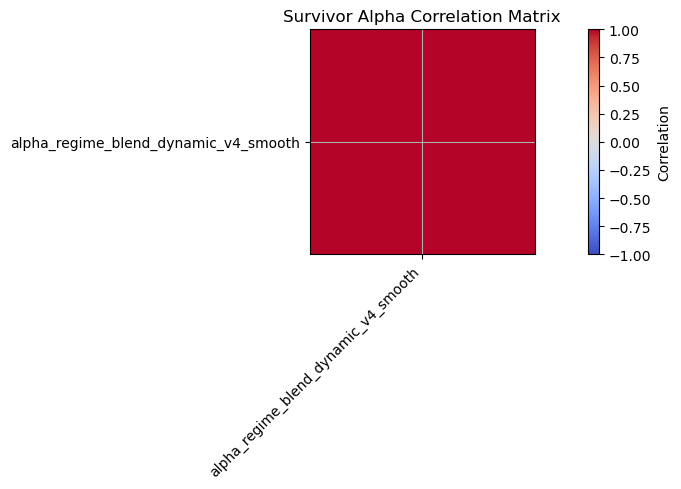

In [20]:
corr_matrix = survivor_correlation_matrix(pre_ml_alpha_inputs, final_survivors)
rolling_corr = rolling_survivor_correlation(pre_ml_alpha_inputs, final_survivors)

display(corr_matrix)
if not survivor_cluster_summary.empty:
    display(survivor_cluster_summary)

if not corr_matrix.empty:
    fig, ax = plt.subplots()
    image = ax.imshow(corr_matrix.values, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr_matrix.index)))
    ax.set_yticklabels(corr_matrix.index)
    ax.set_title("Survivor Alpha Correlation Matrix")
    fig.colorbar(image, ax=ax, label="Correlation")
    plt.tight_layout()
    plt.show()

if not rolling_corr.empty:
    fig, ax = plt.subplots()
    ax.plot(rolling_corr["Date"], rolling_corr["rolling_avg_abs_corr"], label="rolling average absolute correlation")
    ax.set_title("Rolling Survivor Alpha Correlation")
    ax.set_xlabel("Date")
    ax.set_ylabel("Average absolute correlation")
    ax.legend()
    plt.show()

## 8. Regime / Stress Interpretation

In [21]:
stress_wfv_table = stress_wfv_interpretation(final_survivors, alpha_stress_gate, constructed_alpha_wfv_gate)
display(stress_wfv_table)

if not signal_diversity_selection.empty and "selected_flag" in signal_diversity_selection.columns:
    diversity_summary = (
        signal_diversity_selection.groupby(["diversity_group", "selected_flag"], dropna=False)
        .size()
        .reset_index(name="n_signal_horizons")
        .sort_values(["diversity_group", "selected_flag"])
    )
    display(diversity_summary)

,alpha_name,horizon,interpretation_notes,cluster_selection_reason,stress_gate_status,promotion_decision,survivor_tier,pass_rate,worst_degradation,failure_notes,stress_gate_notes,failure_category,wfv_status,effective_mean_test_ic,effective_test_ic_ir,persistence_ratio,sign_consistency,constructed_alpha_wfv_notes
0,alpha_regime_blend_dynamic_v4_smooth,20,High average performance but failed catastroph...,Best eligible alpha from a distinct behavior c...,APPROVED_STRESS,REVIEW_SATELLITE,WATCH_STRESS_SURVIVOR,0.888889,0.422319,execution_delay/0d_delay: n_obs=569167; subper...,Passes majority of stress cases with no fatal ...,NONE,WATCHLIST_CONSTRUCTED_ALPHA_WFV,0.046854,0.72632,0.5,0.75,Meets secondary constructed alpha WFV thresholds.


,diversity_group,selected_flag,n_signal_horizons
0,ORTHOGONAL_DIVERSIFIER_SELECTED,1,1


## 9. Final Dashboard Conclusion

In [22]:
verification_checks = {
    "has_final_survivors": len(final_survivors) > 0,
    "has_pre_ml_rows_for_final_survivors": not pre_ml_alpha_inputs.empty and set(survivor_names).issubset(set(pre_ml_alpha_inputs.get("alpha_name", pd.Series(dtype=object)).dropna().unique())),
    "has_portfolio_performance": not portfolio_performance_summary.empty,
    "has_portfolio_backtest_returns": not portfolio_backtest_results.empty,
    "pre_ml_only_final_core": set(pre_ml_alpha_inputs.get("alpha_name", pd.Series(dtype=object)).dropna().unique()).issubset(set(survivor_names)),
}
verification_table = pd.DataFrame(
    [{"check_name": name, "passed": bool(passed)} for name, passed in verification_checks.items()]
)
readiness_summary = expansion_readiness_summary(
    final_survivors=final_survivors,
    performance_summary=portfolio_performance_summary,
    verification_checks_pass=all(verification_checks.values()),
)

display(verification_table)
display(readiness_summary)

gc.collect()
if 'cleanup_memory' in globals():
    cleanup_memory('after dashboard diagnostics')

,check_name,passed
0,has_final_survivors,True
1,has_pre_ml_rows_for_final_survivors,True
2,has_portfolio_performance,True
3,has_portfolio_backtest_returns,True
4,pre_ml_only_final_core,True


,current_best_portfolio_method,current_best_portfolio_mode,current_best_sharpe,current_max_drawdown,current_turnover,n_final_survivors,verification_checks_pass,expansion_readiness_flag
0,equal_weight_survivors,long_only_top,0.674525,-0.365286,0.024172,1,True,NOT_READY_FOR_EXPANSION
